## Task 1: The Via Ferrata DP Problem (Programming)

Imagine an $N \times M$ grid representing a climbing wall or via ferrata rock face, where each cell contains an "energy cost" to traverse. 

**Your Goal:** Find the path from the bottom-left to the top-right that requires the absolute minimum total energy. You are only allowed to move **Up** or **Right**.

Write a Dynamic Programming algorithm that populates a cost matrix and returns the minimum energy required to reach the top.

In [1]:
import numpy as np

# The Via Ferrata Rock Face (Energy cost per grid cell)
# Start is bottom-left (grid[-1][0]), Goal is top-right (grid[0][-1])
rock_face = np.array(
    [[8, 2, 9, 4, 1], [3, 7, 5, 1, 2], [4, 3, 2, 8, 5], [1, 6, 4, 3, 7]]
)

In [6]:
def optimal_climb_dp(grid):
    rows, cols = grid.shape
    # Create a DP table of the same size, initialized to infinity
    dp = np.full((rows, cols), np.inf)

    # We start at the bottom-left.
    # Let's flip the grid upside down mathematically to make indexing easier
    # (so start is 0,0 and goal is rows-1, cols-1)
    grid_flipped = np.flipud(grid)

    # Base case: Starting position energy cost
    dp[0][0] = grid_flipped[0][0]

    # Fill the first column (can only move up)
    for i in range(1, rows):
        dp[i][0] = dp[i - 1][0] + grid_flipped[i][0]

    # Fill the first row (can only move right)
    for j in range(1, cols):
        dp[0][j] = dp[0][j - 1] + grid_flipped[0][j]

    # Fill the rest of the table
    for i in range(1, rows):
        for j in range(1, cols):
            # The minimum energy to reach this cell is the cost of the cell itself
            # PLUS the minimum of the two possible previous steps (from below or from left)
            dp[i][j] = grid_flipped[i][j] + min(dp[i - 1][j], dp[i][j - 1])

    return dp[rows - 1][cols - 1]


min_energy = optimal_climb_dp(rock_face)
print(f"The minimum energy required to reach the top is: {min_energy}")
# Expected Output: 19

The minimum energy required to reach the top is: 19.0


---
## 💡 Optional Visual Aid: How the DP Algorithm Works

*Note: This section is purely an interactive visualization to help you understand Dynamic Programming! It is not relevant for the exam.*

Dynamic Programming can be hard to visualize in your head. The code below generates an interactive animation of the `optimal_climb_dp` function you just wrote. 

Use the slider to walk through the algorithm step-by-step. 
1. Watch how it pre-calculates the absolute minimum energy required to reach **every single cell**.
2. Once the table is fully populated, watch how it "backtracks" from the goal, simply choosing the smallest number at each step to trace the perfect path!

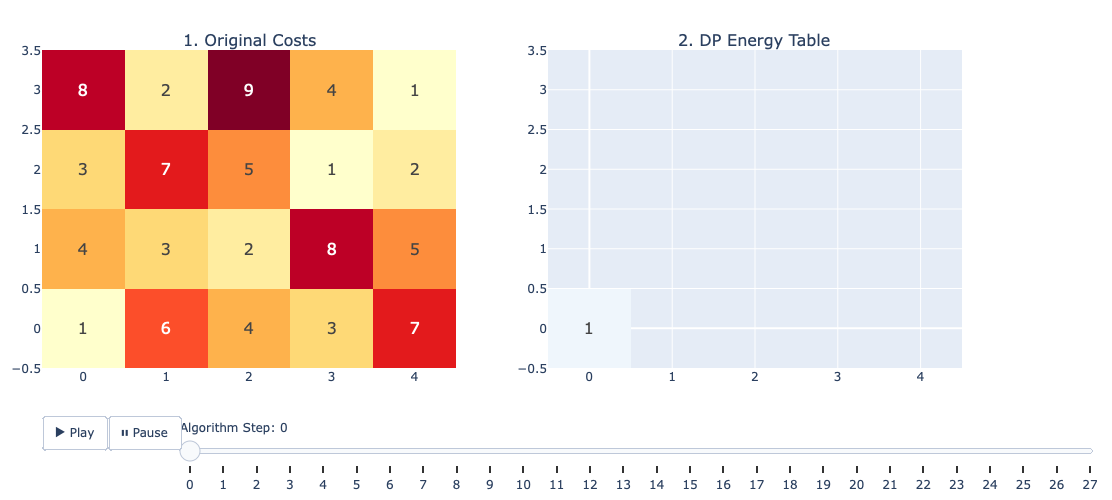

In [10]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# The original rock face from Task 1
rock_face = np.array([
    [8, 2, 9, 4, 1],
    [3, 7, 5, 1, 2],
    [4, 3, 2, 8, 5],
    [1, 6, 4, 3, 7]
])

# Flip the rock face mathematically so [0,0] is the bottom-left start
grid = np.flipud(rock_face)
rows, cols = grid.shape

# --- 1. Precompute all DP states for the animation ---
dp_states = []
current_dp = np.full((rows, cols), np.nan)

# Base case
current_dp[0, 0] = grid[0, 0]
dp_states.append(current_dp.copy())

# First column
for i in range(1, rows):
    current_dp[i, 0] = current_dp[i-1, 0] + grid[i, 0]
    dp_states.append(current_dp.copy())

# First row
for j in range(1, cols):
    current_dp[0, j] = current_dp[0, j-1] + grid[0, j]
    dp_states.append(current_dp.copy())

# Rest of the grid
for i in range(1, rows):
    for j in range(1, cols):
        current_dp[i, j] = grid[i, j] + min(current_dp[i-1, j], current_dp[i, j-1])
        dp_states.append(current_dp.copy())

# --- 2. Precompute the backtracking path ---
i, j = rows-1, cols-1
path = [(i, j)]
while i > 0 or j > 0:
    if i == 0:
        j -= 1
    elif j == 0:
        i -= 1
    else:
        if current_dp[i-1, j] < current_dp[i, j-1]:
            i -= 1
        else:
            j -= 1
    path.append((i, j))

path_states = []
current_path = []
for step in reversed(path):
    current_path.append(step)
    path_states.append(list(current_path))

# --- 3. Build the Native Plotly Figure ---
fig = make_subplots(rows=1, cols=2, subplot_titles=("1. Original Costs", "2. DP Energy Table"))

max_val = np.nanmax(dp_states[-1])

# Trace 0: Original Grid (Static)
fig.add_trace(go.Heatmap(
    z=grid, text=grid, texttemplate="%{text}", textfont={"size": 16},
    colorscale="YlOrRd", showscale=False, hoverinfo="none"
), row=1, col=1)

# Trace 1: DP Grid (Initial State)
text_dp_init = [[f"{val:.0f}" if not np.isnan(val) else "" for val in row] for row in dp_states[0]]
fig.add_trace(go.Heatmap(
    z=dp_states[0], text=text_dp_init, texttemplate="%{text}", textfont={"size": 16},
    colorscale="Blues", zmin=0, zmax=max_val, showscale=False, hoverinfo="none"
), row=1, col=2)

# Trace 2: Path on Original (Initial Empty State)
fig.add_trace(go.Scatter(x=[], y=[], mode="markers+lines", 
                         marker=dict(color="lime", size=10), line=dict(color="lime", width=4), 
                         showlegend=False, hoverinfo="none"), row=1, col=1)

# Trace 3: Path on DP (Initial Empty State)
fig.add_trace(go.Scatter(x=[], y=[], mode="markers+lines", 
                         marker=dict(color="lime", size=10), line=dict(color="lime", width=4), 
                         showlegend=False, hoverinfo="none"), row=1, col=2)

# --- 4. Generate Frames ---
frames = []
total_steps = len(dp_states) + len(path_states)

for k in range(total_steps):
    # Determine the current state based on step index
    if k < len(dp_states):
        z_dp = dp_states[k]
        p_trace = []
    else:
        z_dp = dp_states[-1]
        p_trace = path_states[k - len(dp_states)]

    text_dp = [[f"{val:.0f}" if not np.isnan(val) else "" for val in row] for row in z_dp]

    x_coords, y_coords = [], []
    if p_trace:
        y_coords, x_coords = zip(*p_trace) # Note: indices are (row, col) which translates to (y, x)

    # Create the frame updating Traces 1, 2, and 3
    frames.append(go.Frame(
        data=[
            go.Heatmap(z=z_dp, text=text_dp),  # Updates Trace 1
            go.Scatter(x=x_coords, y=y_coords), # Updates Trace 2
            go.Scatter(x=x_coords, y=y_coords)  # Updates Trace 3
        ],
        traces=[1, 2, 3],
        name=f'{k}'
    ))

fig.frames = frames

# --- 5. Layout, Slider, and Buttons ---
slider_steps = [
    dict(method='animate', 
         args=[[f'{k}'], dict(mode='immediate', frame=dict(duration=200, redraw=True), transition=dict(duration=0))], 
         label=f'{k}') 
    for k in range(total_steps)
]

fig.update_layout(
    height=500,
    margin=dict(t=50, b=20, l=20, r=20),
    updatemenus=[dict(
        type="buttons", direction="left", showactive=False,
        x=0.0, y=-0.15, xanchor="left", yanchor="top",
        buttons=[
            dict(label="▶ Play", method="animate", args=[None, dict(frame=dict(duration=200, redraw=True), fromcurrent=True, transition=dict(duration=0))]),
            dict(label="⏸ Pause", method="animate", args=[[None], dict(frame=dict(duration=0, redraw=True), mode="immediate", transition=dict(duration=0))])
        ]
    )],
    sliders=[dict(
        active=0, x=0.15, y=-0.15, xanchor="left", yanchor="top", pad=dict(t=0),
        currentvalue=dict(prefix="Algorithm Step: ", font=dict(size=12)), steps=slider_steps
    )]
)

fig.show()

---
## Task 2: Continuous Probability Density (Theory)

Physical processes might be deterministic, but our measured data never is due to inherent uncertainty. As the number of measurements approaches infinity, the discrete blocks of a relative frequency histogram smooth out into a continuous **Probability Density Function (PDF)** where the total area integrates to $1$.

Consider a measurement error represented by the simple polynomial PDF:
$$f(x) = \begin{cases} c x^2 & \text{for } x \in [0, 2] \\ 0 & \text{otherwise} \end{cases}$$

**Tasks:**
1. Determine the constant $c$ such that $f(x)$ is a valid Probability Density Function.
2. Calculate the probability that a random measurement falls in the interval $x \in [1, 2]$.

<details>
<summary><b>Click to reveal the Theoretical Solution</b></summary>

**Part 1: Finding $c$**
For $f(x)$ to be a valid PDF, the total area under the curve must equal $1$:
$$\int_0^2 c x^2 dx = 1$$
$$c \left[ \frac{x^3}{3} \right]_0^2 = 1$$
$$c \left( \frac{8}{3} - 0 \right) = 1$$
$$c = \frac{3}{8}$$

Therefore, the valid PDF is $f(x) = \frac{3}{8} x^2$.

**Part 2: Calculating Probability over an Interval**
To find $P(1 \le x \le 2)$, we integrate the valid PDF over that specific interval:
$$P(1 \le x \le 2) = \int_1^2 \frac{3}{8} x^2 dx$$
$$P(1 \le x \le 2) = \frac{3}{8} \left[ \frac{x^3}{3} \right]_1^2$$
$$P(1 \le x \le 2) = \frac{3}{8} \left( \frac{8}{3} - \frac{1}{3} \right)$$
$$P(1 \le x \le 2) = \frac{3}{8} \left( \frac{7}{3} \right) = \frac{7}{8} = 0.875$$

There is an $87.5\%$ probability the measurement falls between $1$ and $2$.
</details>

---
## Task 3: Empirical Statistics vs. The PDF (Programming)

Now we will prove the concept from Task 2 using code. We will use a complex Gaussian measurement error instead of a simple polynomial. 

**Your Goal:**
1. Use `scipy.stats` to calculate the exact theoretical probability of a measurement falling between $0.2$ and $0.8$ given a normal distribution ($\mu = 0$, $\sigma = 0.5$).
2. Run a Monte Carlo simulation generating $100,000$ random measurements using `numpy`. Calculate the empirical relative frequency of measurements falling in that same bin and compare the two numbers.

In [5]:
import numpy as np
import scipy.stats as stats

# Define a measurement error with Mean = 0, Standard Deviation = 0.5
mu = 0
sigma = 0.5

# --- 1. THE THEORETICAL INTEGRAL (Using scipy) ---
# Find the probability that the error falls between 0.2 and 0.8
# P(0.2 < x < 0.8) = CDF(0.8) - CDF(0.2)
prob_theoretical = stats.norm.cdf(0.8, mu, sigma) - stats.norm.cdf(0.2, mu, sigma)
print(f"Theoretical PDF Probability: {prob_theoretical:.4f}")

# --- 2. THE EMPIRICAL SIMULATION (Monte Carlo) ---
# Generate 100,000 random simulated measurements
np.random.seed(42)  # For reproducible results
measurements = np.random.normal(mu, sigma, 100000)

# Count how many measurements actually fell into our bin [0.2, 0.8]
measurements_in_bin = np.sum((measurements > 0.2) & (measurements < 0.8))

# Calculate the relative frequency (R(x_i) from the lecture)
prob_empirical = measurements_in_bin / 100000
print(f"Empirical Simulated Probability: {prob_empirical:.4f}")

Theoretical PDF Probability: 0.2898
Empirical Simulated Probability: 0.2896
